# <span style="color:red; font-size: 30px"> Assignment 10 - Due Thursday, April 23rd at 8am ET</span>

<font size = "3">

This is a graded homework assignment - no part may be used within a prompt to an LLM

Complete the code cells in this Jupyter notebook, and submit the final .ipynb notebook to Gradescope.

**Please do the following in VS code before you submit**:

- Click "Clear All Outputs"

- Click "Restart"

- Run all code cells

- Save the file

**Note:** Output should match the code that appears in its corresponding cell.

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt

<font size = "4">

**(a) Aggregate Statistics and Merging**

<font size = "3">

1. Read in the files "product_metadata.csv" and "transaction_data.csv" from the data folder, assigning them to DataFrames `df_product` and `df_transaction`, respectively.

2. Merge the two DataFrames together based on the variable "ProductID", creating a new DataFrame called `df_merged`. It should have the following structure:

    - It should have 8 columns. The first 6 columns correspond to the 6 columns in `df_transaction`. The last 2 columns should be "Category" and "UnitPrice" from `df_product`.

    - The ordering of the rows should be inherited from the row ordering in `df_transaction`.

    - Only a single use of `pd.merge` should be used. Only merge the required columns, do **not** drop any columns after performing the merge.

3. Add a column to `df_merged` named "TransactionRevenue" based on the following formula:

$$\textrm{TransactionRevenue} = \textrm{Quantity} \times \textrm{UnitPrice}$$

4. Group `df_merged` by "Category". Create a new DataFrame called `df_agg` by aggregating the following statistics over each category with a single call of the `.agg` method:

    - The average TransactionRevenue

    - The maximum UnitPrice

5. Create a DataFrame called `df_final` by merging the new DataFrame `df_agg` with `df_merged`. The row ordering of `df_final` should be inherited from `df_merged`.

In [2]:
# your code here
df_product = pd.read_csv("data/product_metadata.csv")
df_transaction = pd.read_csv("data/transaction_data.csv")

df_merged = pd.merge(df_transaction, df_product[["ProductID","Category","UnitPrice"]],on = "ProductID")
df_merged["TransactionRevenue"] = df_merged["Quantity"] * df_merged["UnitPrice"]

df_agg = df_merged.groupby("Category").agg(AvgTransactionRevenue = ("TransactionRevenue","mean") , MaxUnitPrice = ("UnitPrice","max") ).reset_index()
df_final = pd.merge(df_merged, df_agg, on = "Category")

<font size = "4">

**For the last 4 questions, you may find "lecture_time_series_1" and "lecture_time_series_2" in the GitHub repo to be helpful.**

<font size = "4">

**(b) DateTime Conversion**

<font size = "3">

1. Read in the file "timeseries_data.csv" from the data folder, assigning it to a DataFrame.

2. The 'timestamp' column consists of strings, which will be sorted alphabetically instead of chronologically. Use `pd.to_datetime` to overwrite the 'timestamp' column with one that is properly formatted for time. (There will be a warning message that can be suppressed by adding the argument `format = 'mixed'`)

3. Create a DataFrame called `df_sorted` which is sorted in **descending** order by "timestamp".

4. Use the `.to_csv` method to save `df_sorted` in the data folder as "time_series_cleaned.csv". You should **not** include the index column in the saved file.

In [3]:
# your code here
df = pd.read_csv("data/timeseries_data.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"], format = "mixed")
df_sorted = df.sort_values("timestamp", ascending = False)
df_sorted.to_csv("data/time_series_cleaned.csv", index = False)

<font size = "4">

**(c) Plotting time series data**

<font size = "3">

- Continue to use `df_sorted` created in the previous question (or re-read it from "timeseries_cleaned.csv" and convert the 'timestamp' column to datetime format again.)

- Use ``plt.plot`` to create a line plot showing the relationship between time (on the horizontal axis) and energy consumption (on the vertical axis) using the appropriate columns from `df_sorted`.

- Label the axes and add a title to the plot.

- In addition, execute the command `plt.xticks(rotation = 45)` before running `plt.show()` to improve the formatting of the time along the horizontal axis.

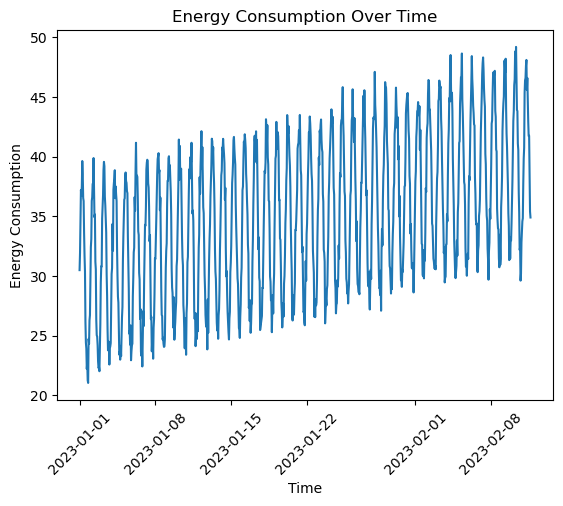

In [4]:
# your code here
df_sorted = pd.read_csv("data/time_series_cleaned.csv")
df_sorted["timestamp"] = pd.to_datetime(df_sorted["timestamp"], format = "mixed")

plt.plot(df_sorted["timestamp"], df_sorted["energy_kwh"])
plt.xlabel("Time")
plt.ylabel("Energy Consumption")
plt.title("Energy Consumption Over Time")
plt.xticks(rotation = 45)
plt.show()

<font size = "4">

**(d) Highlight regions beyond temperature threshold**

<font size = "3">

- Continue to use `df_sorted` created above (or re-read it from "timeseries_cleaned.csv" and convert the 'timestamp' column to datetime format again.)

- Create a Pandas Series named `above_temp` that contains the value `True` in every row where `df_sorted['temp_celsius']` is strictly greater than 25, and is `False` otherwise. **Hint:** You just need to use a single Boolean comparison operator for this part.

- Run the command `plt.figure(figsize=(12, 6))` (this will end up making a better-looking figure)

- Create a line plot of time against temperature (in Celsius) using the appropriate columns of `df_sorted`. Include the input argument `label = 'Temperature'`

- Call the function `plt.fill_between` with the following input arguments:

    - `x`: the time data from the DataFrame

    - `y1`: the temperature data from the DataFrame
    - `y2`: the integer 25 (our threshold value)
    - `where`: the Boolean Pandas Series you created above
    - `label`: the string "Above threshold (25 degrees)"
    - `facecolor`: the string "red"
    - `alpha`: the number 0.5

- Add labels and a title to the figure, and use `plt.legend()` to add a legend. In addition, rotate the x-axis tick marks by 45 degrees, like you did in the previous problem. As always, finish off your plot with `plt.show()`

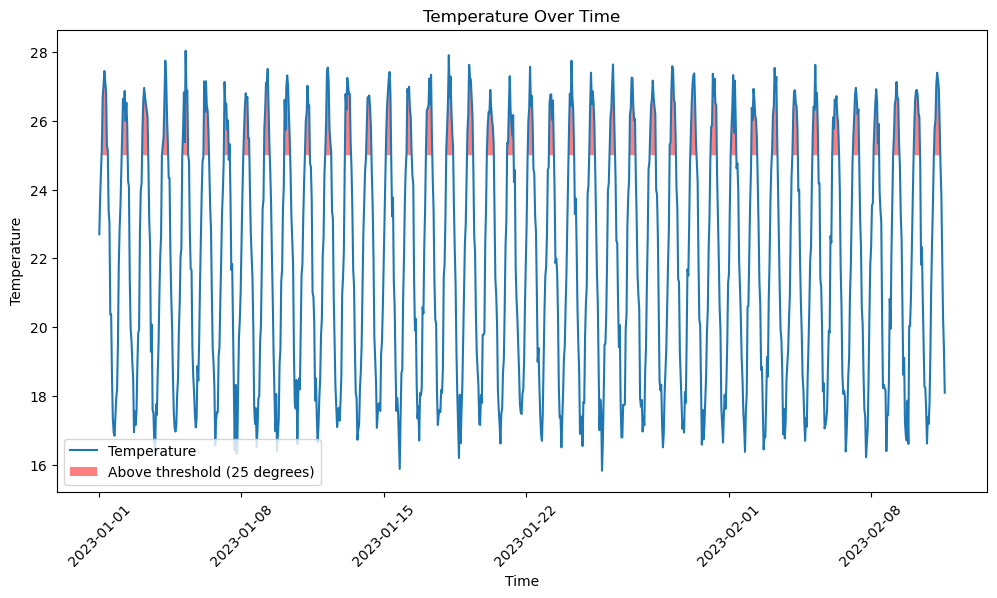

In [5]:
# your code here
df_sorted = pd.read_csv("data/time_series_cleaned.csv")
df_sorted["timestamp"] = pd.to_datetime(df_sorted["timestamp"], format = "mixed")

above_temp = df_sorted["temp_celsius"] > 25

plt.figure(figsize=(12, 6))
plt.plot(df_sorted["timestamp"], df_sorted["temp_celsius"], label="Temperature")
plt.fill_between(x = df_sorted["timestamp"], y1 = df_sorted["temp_celsius"],y2= 25, where=above_temp, label="Above threshold (25 degrees)", facecolor="red", alpha=0.5)
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.title("Temperature Over Time")
plt.legend()
plt.xticks(rotation = 45)
plt.show()

<font size = "4">

**(e) Percentage growth rate**

<font size = "3">

- Continue to use `df_sorted` created above (or re-read it from "timeseries_cleaned.csv" and convert the 'timestamp' column to datetime format again.)

- Add a new column to the DataFrame called "growth_temp" that calculates the hourly percentage change in temperature. This can be done in an easier way than what is demonstrated in "time_series_1.ipynb":

    - Extract the column of the DataFrame corresponding to temperature and use the `.pct_change()` method to calculate percentage change as a decimal.

    - Multiply by 100 to represent this value as a standard percentage.


- We next want to calculate the maximum percentage change in temperature **and** when it occurred. In order to do this, perform the following steps:

    - Extract the "growth_temp" column you added to the DataFrame and use the `.idxmax()` method to get the row label corresponding to the largest value.

    - Use `.loc` twice to access the maximum percentage temperature change and the time it occurred from the DataFrame. Assign these quantities to the variables `max_pct_change` and `max_time`, respectively.

In [6]:
# your code here

df_sorted["growth_temp"] = df_sorted["temp_celsius"].pct_change() * 100

max_idx= df_sorted["growth_temp"].idxmax()
max_pct_change = df_sorted.loc[max_idx, "growth_temp"]
max_time = df_sorted.loc[max_idx, "timestamp"]

# max_pct_change = 0.0
# max_time = 0.0

print(f"Largest hourly increase occurred at: {max_time}")
print(f"The growth rate at that time was: {max_pct_change:.2f}%")


Largest hourly increase occurred at: 2023-01-03 12:00:00
The growth rate at that time was: 16.13%
